**Técnicas de Aprendizaje Automático**

_Máster Universitario en Inteligencia Artificial_

# Laboratorio: Regresión lineal y árboles de decisión para tareas de regresión


## Objetivos

Mediante esta actividad se pretende que el alumno ponga en práctica los pasos para la resolución de un problema de machine learning, el tratamiento de datos y la creación de modelos basados en regresión lineal y árboles de decisión. El objetivo es comprender de forma práctica con un problema determinado las diferencias que existen a la hora de entrenar los diferentes modelos.

- Iniciarse en el Análisis Exploratorio de Datos (EDA) para los problemas de Machine Learning.
- Entender y aplicar los conceptos de la Regresión Lineal Múltiple a un problema de **regresión**.
- Entender y aplicar los conceptos de Árboles de Decisión a un problema de **regresión**.
- Evaluar y analizar los resultados de los clasificadores.
- Investigar la aplicación de los modelos de **regresión** a problemas reales.


## Descripción de la actividad

Debes completar los espacios indicados en el notebook con el código solicitado y la respuesta en texto, en función de lo que se solicite. Ten en cuenta que las celdas vacías indican cuántas líneas debe ocupar dicha respuesta, por lo general no más de una línea.

El conjunto de datos con el que vamos a trabajar se encuentra en el siguiente enlace: https://archive.ics.uci.edu/dataset/360/air+quality

Se trata de un conjunto de datos (dataset) sobre calidad del aire. En total cuenta con 9358 instancias de respuestas promediadas por hora de una matriz de 5 sensores químicos de óxido de metal integrados en un dispositivo multisensor químico de calidad del aire. El dispositivo estaba ubicado en un área significativamente contaminada, al nivel de la carretera, dentro de una ciudad italiana. Los datos se registraron desde marzo de 2004 hasta febrero de 2005 (un año).

El objetivo de la regresión será predecir la calidad del aire para un determinado día.

### Tareas que se deben realizar

- Análisis descriptivo de los datos:
   - Debe completarse el código solicitado y responder a las preguntas. Todo ello en el notebook dado como base.
- Regresión:
  - Debe completarse el código solicitado y responder a las preguntas. Todo ello en el notebook dado como base.
- Investigación:
  - Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de **regresión** empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.
  - Para el artículo indicar:
    - Objetivo: cuál es el objetivo de la investigación, es decir a qué problema real está aplicando la regresión.
    - Cómo utilizan las técnicas de regresión, si realizan alguna adaptación de los algoritmos indicarse.
    - Principales resultados de la aplicación y de la investigación.


### Análisis descriptivo de los datos
A continuación vas a encontrar una serie de preguntas que tendrás que responder. Para responder tendrás que escribir (y ejecutar) una (o más de una) línea de código, y a continuación indicar la respuesta en la celda indicada.

In [1]:
## cargar el dataset
# Importar pandas
import pandas as pd

# Cargar el dataset
df = pd.read_csv("AirQualityUCI.csv", sep=";", decimal=",")

print('Filas, columnas',df.shape)
# Ver las primeras 5 filas
df.head()

Filas, columnas (9471, 17)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


### ¿cuántas instancias tiene el dataset?

In [31]:
import pandas as pd
import numpy as np

# PASO 1: Detectar filas problematicas
lineas_problematicas = []
with open('AirQualityUCI.csv', 'r', encoding='latin-1') as f:
    for indice, linea in enumerate(f):
        stripped = linea.strip()
        # Fila vacía o solo separadores
        if stripped == '' or all(c in ';\n\r ' for c in stripped):
            lineas_problematicas.append(indice)

print(f"Filas problemáticas encontradas: {len(lineas_problematicas)}")

# PASO 2: Cargar saltando filas problematicas
df = pd.read_csv(
    'AirQualityUCI.csv',
    sep=';',
    decimal=',',
    #na_values=['-200', '-200.0', '-100', '-100.0', ''],
    skiprows=lineas_problematicas
)

# PASO 3: Eliminar columnas completamente vacías
columnas_vacias = [col for col in df.columns if df[col].isnull().all()]
df = df.drop(columns=columnas_vacias)

print(f"Filas finales: {len(df)}")
print(f"Columnas finales: {len(df.columns)}")
print(f"Shape: {df.shape}")

# PASO 4: Verificar información
print(f"\nValores NaN por columna:")
print(df.isnull().sum())

Filas problemáticas encontradas: 114
Filas finales: 9357
Columnas finales: 15
Shape: (9357, 15)

Valores NaN por columna:
Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


In [32]:
## ¿cuántas instancias tiene el dataset?
df.shape

(9357, 15)

## Respuesta

El dataset tiene **9472 instancias**.

Inicialmente, el dataset tenía **9472 instancias** en el archivo CSV.  Se realizó una limpieza de las **últimas 114 filas**, las cuales estaban vacías y solo contenían separadores (`;;;;`). Una vez realizada la limpieza, quedaron **9357 instancias**.  Este valor es consistente con la documentación oficial de **UCI (9358)**, existiendo una **diferencia mínima de una instancia**.

### ¿cuál es el tipo de datos de cada una de las columnas?

In [33]:
## ¿cuál es el tipo de datos de cada una de las columnas?
print("Validación: ¿Columnas numéricas tienen decimales?")
print("-"*60)
for col in df.select_dtypes(include=['number']).columns:
    tiene_decimal = any(df[col].dropna() % 1 != 0)
    print(f"{col}: {' Tiene decimales' if tiene_decimal else '- Solo enteros'}")

print("\nResumen de tipos:")
print(df.dtypes.value_counts())
print(df.dtypes)

Validación: ¿Columnas numéricas tienen decimales?
------------------------------------------------------------
CO(GT):  Tiene decimales
PT08.S1(CO): - Solo enteros
NMHC(GT): - Solo enteros
C6H6(GT):  Tiene decimales
PT08.S2(NMHC): - Solo enteros
NOx(GT): - Solo enteros
PT08.S3(NOx): - Solo enteros
NO2(GT): - Solo enteros
PT08.S4(NO2): - Solo enteros
PT08.S5(O3): - Solo enteros
T:  Tiene decimales
RH:  Tiene decimales
AH:  Tiene decimales

Resumen de tipos:
int64      8
float64    5
object     2
Name: count, dtype: int64
Date              object
Time              object
CO(GT)           float64
PT08.S1(CO)        int64
NMHC(GT)           int64
C6H6(GT)         float64
PT08.S2(NMHC)      int64
NOx(GT)            int64
PT08.S3(NOx)       int64
NO2(GT)            int64
PT08.S4(NO2)       int64
PT08.S5(O3)        int64
T                float64
RH               float64
AH               float64
dtype: object


### Respuesta

El dataset contiene dos tipos de datos principales:

### Tipos de secuencia (object)
- **Date**: formato `DD/MM/YYYY`
- **Time**: formato `HH.MM.SS`

### Tipos numéricos

- **Enteros (`int64`)(**8 columnas**)**:  
  PT08.S1(CO), NMHC(GT), PT08.S2(NMHC), NOx(GT), PT08.S3(NOx), NO2(GT), PT08.S4(NO2), PT08.S5(O3)  
  

- **Flotantes (`float64`)**(**5 columnas**):  
  CO(GT), C6H6(GT), T, RH, AH  
  

Las columnas numéricas se dividen en `int64` y `float64` debido a que algunas contienen valores decimales y otras solo valores enteros.


## ¿cuántas columnas categóricas hay? ¿y cuántas continuas?

In [34]:
## ¿cuántas columnas categóricas hay? ¿y cuántas continuas?
print("Columnas categóricas (object):")
print(df.select_dtypes(include=['object']).columns.tolist())

print("\nColumnas discretas (int64):")
print(df.select_dtypes(include=['int64']).columns.tolist())

print("\nColumnas continuas (float64):")
print(df.select_dtypes(include=['float64']).columns.tolist())

Columnas categóricas (object):
['Date', 'Time']

Columnas discretas (int64):
['PT08.S1(CO)', 'NMHC(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)']

Columnas continuas (float64):
['CO(GT)', 'C6H6(GT)', 'T', 'RH', 'AH']


### Respuesta

El dataset contiene **15 columnas**, clasificadas según la teoría estadística de la siguiente manera:

### Variables cualitativas (categóricas)

- **Nominales (2 columnas)**:  
  `Date`, `Time`  
  Identifican fecha y hora, sin una relación numérica directa.

### Variables cuantitativas (numéricas)

- **Discretas (8 columnas)**:  
  `PT08.S1(CO)`, `NMHC(GT)`, `PT08.S2(NMHC)`, `NOx(GT)`,  
  `PT08.S3(NOx)`, `NO2(GT)`, `PT08.S4(NO2)`, `PT08.S5(O3)`  
  Representan valores enteros asociados a respuestas de sensores y concentraciones medidas.

- **Continuas (5 columnas)**:  
  `CO(GT)`, `C6H6(GT)`, `T`, `RH`, `AH`  
  Representan valores decimales de concentraciones químicas y variables ambientales que pueden tomar infinitos valores dentro de un rango.

In [36]:
# Ver cuántos -200 hay antes de convertir
print("Valores -200 por columna:")
print((df == -200).sum())

print(f"\nTotal -200: {(df == -200).sum().sum()}")

Valores -200 por columna:
Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64

Total -200: 16701


### Tratamiento de valores faltantes

Según la documentación, en el dataset existen valores faltantes codificados como **-200**, debido a fallas en los sensores químicos.  
Inicialmente se detectó la cantidad de valores faltantes por columna, obteniendo un total de **16 701 valores faltantes**.

La distribución de estos valores es la siguiente:

#### **Columnas con bajo porcentaje de valores faltantes**
Las columnas que contienen **366 valores faltantes** representan aproximadamente el **3.9%** del total.  
Al ser un porcentaje menor al 5%, se propone **eliminar las filas** correspondientes.

#### **Columnas con porcentaje medio de valores faltantes (17–18%)**
Estas columnas presentan un nivel moderado de valores faltantes, por lo que se aplicaria **imputación usando la media o mediana**:

- **CO(GT):** 1683 valores (18%)
- **NOx(GT):** 1639 valores (17.5%)
- **NO2(GT):** 1642 valores (17.5%)

#### **Columnas con alto porcentaje de valores faltantes**
- **NMHC(GT):** 8443 valores faltantes (**90.2%**)

En este caso, el sensor falló casi por completo, por lo que **no se considera necesario imputar** estos valores.

In [37]:
import numpy as np
from sklearn.impute import SimpleImputer

# PASO 1: Eliminar columna NMHC(GT) (90% de datos faltantes)
df = df.drop(columns=['NMHC(GT)'])
print(f"✓ Paso 1: Columna NMHC(GT) eliminada")
print(f"  Columnas actuales: {df.shape[1]}")

# PASO 2: Convertir -200 a NaN
df = df.replace(-200, np.nan)
print(f"\n✓ Paso 2: Valores -200 convertidos a NaN")

# PASO 3: Eliminar 366 filas (período de fallo general)
filas_antes = len(df)
df = df.dropna(subset=['PT08.S1(CO)'])
filas_despues = len(df)
print(f"\n✓ Paso 3: Filas eliminadas: {filas_antes - filas_despues}")
print(f"  Filas restantes: {filas_despues}")

# PASO 4: Imputar CO(GT), NOx(GT), NO2(GT) con media
imputer = SimpleImputer(strategy='mean')
df[['CO(GT)', 'NOx(GT)', 'NO2(GT)']] = imputer.fit_transform(
    df[['CO(GT)', 'NOx(GT)', 'NO2(GT)']]
)
print(f"\n✓ Paso 4: Imputación con media aplicada")

# VERIFICACIÓN FINAL
print(f"\n{'='*50}")
print(f"RESUMEN FINAL:")
print(f"  Shape: {df.shape}")
print(f"  Valores NaN restantes: {df.isnull().sum().sum()}")
print(f"\nNaN por columna:")
print(df.isnull().sum())

✓ Paso 1: Columna NMHC(GT) eliminada
  Columnas actuales: 14

✓ Paso 2: Valores -200 convertidos a NaN

✓ Paso 3: Filas eliminadas: 366
  Filas restantes: 8991

✓ Paso 4: Imputación con media aplicada

RESUMEN FINAL:
  Shape: (8991, 14)
  Valores NaN restantes: 0

NaN por columna:
Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


## Respuesta

El dataset **sí presentaba valores faltantes** codificados con **-200**.  
Se identificaron **16 701 valores faltantes** entre las diferentes columnas numéricas, por lo que se aplicaron las siguientes estrategias para el tratamiento de estos datos:

1. **Eliminación de la columna `NMHC(GT)`**  
   Esta columna tenía más del **90% de datos faltantes**, con **8 443 valores**, lo que indica que faltaban casi todos los datos, por lo que se decidió eliminarla.

2. **Conversión a NaN**  
   Los valores **-200** fueron convertidos a **NaN** para facilitar su procesamiento.

3. **Eliminación de filas con bajo porcentaje de valores faltantes**  
   Se eliminaron las filas de las columnas `PT08.S1(CO)`, `C6H6(GT)`, `PT08.S2(NMHC)`, `PT08.S3(NOx)`, `PT08.S4(NO2)`, `PT08.S5(O3)`, `T`, `RH`, `AH`, que presentaban **366 valores faltantes (3.9%)** por igual.  
   Al ser un porcentaje menor al 5%, se optó por eliminar estas filas. Esto sugiere un fallo general del sensor en un período de tiempo específico.

4. **Imputación con la media**  
   Para las columnas `CO(GT)` (18%), `NOx(GT)` (17.5%) y `NO2(GT)` (17.5%), al presentar un porcentaje moderado de valores faltantes, se decidió reemplazarlos utilizando la **media** de cada columna.

### Resultado final

- **8 991 filas**
- **14 columnas**
- **Sin valores NaN**


CORRELACIONES:
               CO(GT)  C6H6(GT)  NOx(GT)  NO2(GT)
CO(GT)           1.00      0.84     0.75     0.64
PT08.S1(CO)      0.80      0.88     0.65     0.58
C6H6(GT)         0.84      1.00     0.65     0.56
PT08.S2(NMHC)    0.82      0.98     0.64     0.58
NOx(GT)          0.75      0.65     1.00     0.76
PT08.S3(NOx)    -0.64     -0.74    -0.59    -0.59
NO2(GT)          0.64      0.56     0.76     1.00
PT08.S4(NO2)     0.58      0.77     0.22     0.15
PT08.S5(O3)      0.79      0.87     0.73     0.65
T                0.02      0.20    -0.25    -0.17
RH               0.04     -0.06     0.20    -0.08
AH               0.04      0.17    -0.14    -0.30

ESTADÍSTICOS DESCRIPTIVOS:
        CO(GT)  C6H6(GT)  NOx(GT)  NO2(GT)
count  8991.00   8991.00  8991.00  8991.00
mean      2.13     10.08   242.19   112.15
std       1.30      7.45   187.12    43.19
min       0.10      0.10     2.00     2.00
25%       1.20      4.40   112.00    85.00
50%       2.13      8.20   227.00   112.15
75%   

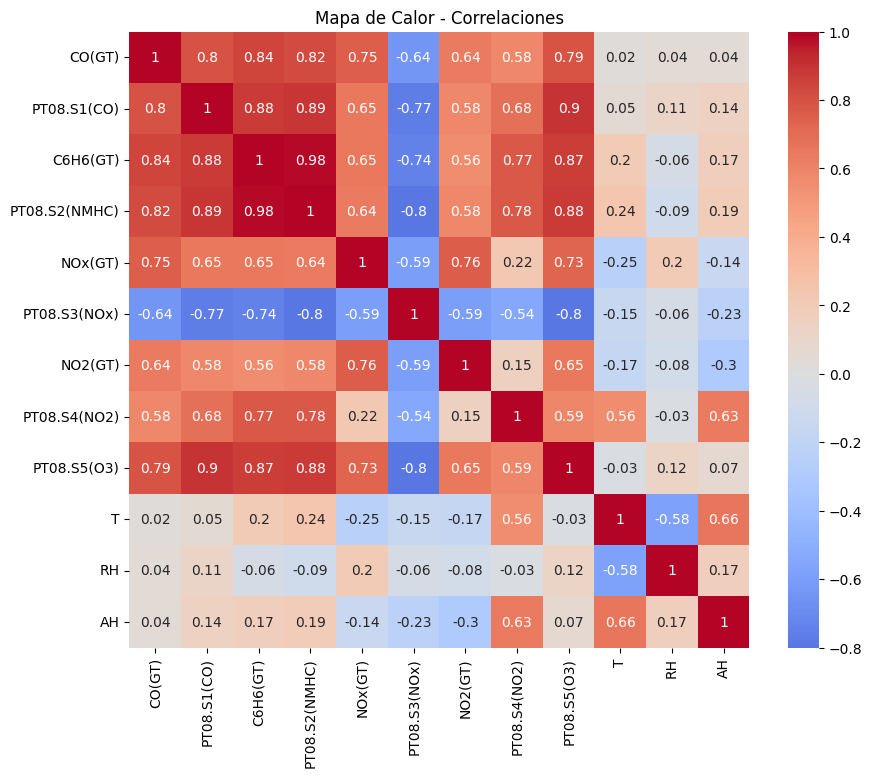

In [45]:
## ¿cuál es la variable respuesta?¿de qué tipo es? (Recuerda justificar por qué la seleccionas)
import seaborn as sns
import matplotlib.pyplot as plt

# ANÁLISIS 1: Correlaciones (solo columnas numéricas)
df_numeric = df.select_dtypes(include=['number'])

print("CORRELACIONES:")
print(df_numeric.corr()[['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']].round(2))

# ANÁLISIS 2: Distribución
print("\nESTADÍSTICOS DESCRIPTIVOS:")
print(df[['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']].describe().round(2))

plt.figure(figsize=(10, 8))
sns.heatmap(df_numeric.corr().round(2),
            annot=True,
            cmap='coolwarm',
            center=0)
plt.title('Mapa de Calor - Correlaciones')
plt.show()

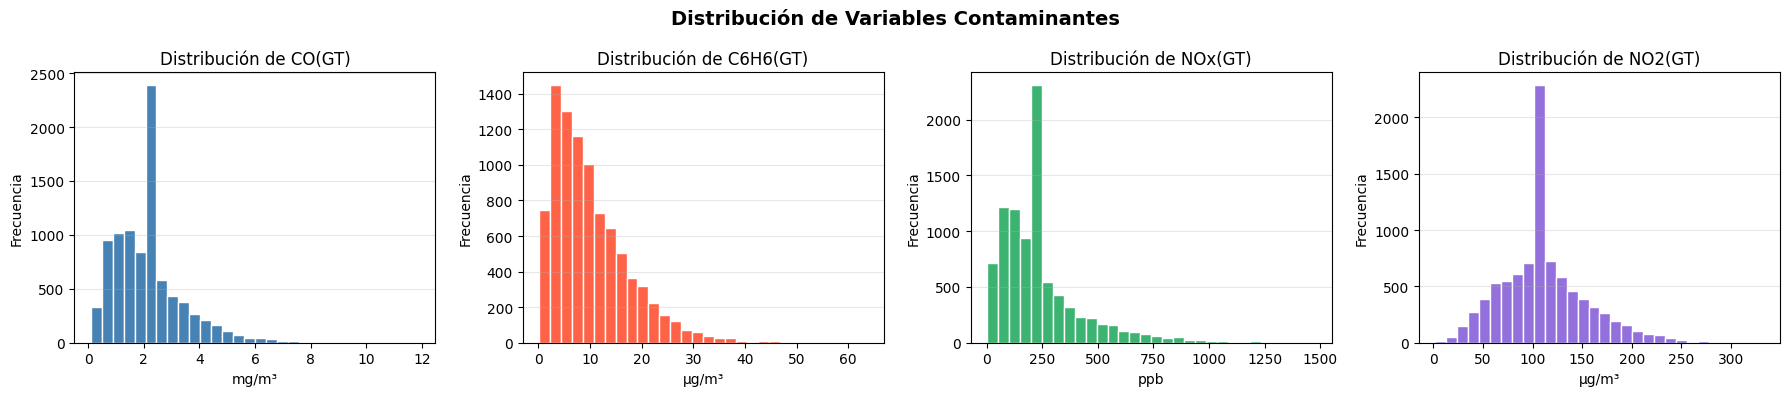

In [46]:
# Configuración de variables
variables = ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']
unidades  = ['mg/m³',  'µg/m³',    'ppb',     'µg/m³']
colores   = ['steelblue', 'tomato', 'mediumseagreen', 'mediumpurple']

# Crear panel 1 fila x 4 columnas
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Distribución de Variables Contaminantes', fontsize=14, fontweight='bold')

for ax, var, unidad, color in zip(axes, variables, unidades, colores):
    ax.hist(df[var], bins=30, color=color, edgecolor='white')
    ax.set_title(f'Distribución de {var}')
    ax.set_xlabel(unidad)
    ax.set_ylabel('Frecuencia')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Selección de la variable objetivo

Según la documentación de **UCI**, el dataset contiene **4 variables objetivo**, medidas mediante instrumentos de referencia certificados:

- **CO(GT)**: Concentración de monóxido de carbono (mg/m³)
- **C6H6(GT)**: Concentración de benceno (µg/m³)
- **NOx(GT)**: Concentración de óxidos de nitrógeno (ppb)
- **NO2(GT)**: Concentración de dióxido de nitrógeno (µg/m³)

Los valores de estas variables fueron obtenidos mediante **medidas de referencia certificada**, es decir, utilizando instrumentos de alta precisión.

### Variable seleccionada

Para este caso, se seleccionó la variable **`C6H6(GT)`** (concentración de benceno en µg/m³), en base a los siguientes criterios:

- **Correlación**  
  Según el mapa de calor, `C6H6(GT)` presenta la **correlación promedio más alta** entre las variables objetivo:
  - `PT08.S2(NMHC)`: r = 0.98  
  - `PT08.S1(CO)`: r = 0.88  
  - `PT08.S5(O3)`: r = 0.87  

- **Valores faltantes**  
  Solo presenta un **3.9% de datos faltantes**, siendo una de las variables con menor porcentaje en comparación con las demás.

- **Distribución de los datos**  
  Según el histograma, la variable presenta una distribución en un rango razonable de **0.10 a 63.70 µg/m³**, con pocos valores atípicos extremos y una **desviación estándar manejable (7.45)**.  
  En contraste, variables como `NOx(GT)` presentan muchos valores atípicos que alcanzan hasta **1500 ppb**.

- **Tipo de variable**  
  Es una **variable cuantitativa continua** (`float64`), es ideal para para problemas de regresion segun lo revisado en el Tema 4.

In [ ]:
## Si te fijas en los estadísticos del dataset, ¿cómo es la distribución de las variables, CO, NOx y NO2?

_indica aquí tu respuesta_

¿Estas variables muestran alguna distribución especial?¿Tienen datos faltantes?¿y datos anómalos?

_indica aquí tu respuesta_

In [ ]:
## ¿cómo son las correlaciones entre las variables del dataset?

_indica aquí tu respuesta_

In [ ]:
## ¿qué tres variables son las más correlacionadas con la variable objetivo?

_indica aquí tu respuesta_

In [ ]:
## ¿existe alguna variable que no tenga correlación?

_indica aquí tu respuesta_

En base al EDA realizado, ¿qué suposiciones se pueden hacer sobre los datos?¿qué conclusiones extraes para implementar el modelo predictivo?

_indica aquí tu respuesta_

### Regresión

Para llevar a cabo la tarea de regresión deseada se pretender hacer una comparativa de varios modelos. Unos usarán el algoritmo de regresión lineal, y otros realizarán la predicción haciendo uso de árboles de decisión.

Para los primeros modelos hay que usar el módulo https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

El algoritmo de Regresión Lineal, necesita saber cuáles son las variables que va a tener en cuenta para realizar la estimación.

El primer modelo que se debe construir, usará una regresión lineal simple. Para ello sigue los siguientes pasos.

Antes de empezar con la implementación de los modelos hace falta realizar una transformación de datos, escalarlos.

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from pandas import DataFrame


scaler = StandardScaler()

X_train = DataFrame(scaler.fit_transform(X_train))
X_test = DataFrame(scaler.fit_transform(X_test))

In [ ]:
# separar datos de entrenamiento y test

In [ ]:
# escoger la variable que a partir del EDA realizado, consideres que mejor va a realizar la predicción

In [ ]:
# entrena el modelo con los datos de entrenamiento

In [ ]:
# ¿cuáles son los valores aprendidos por el modelo para los parámetros?

Explica qué indican estos parámetros

_indica aquí tu respuesta_

In [ ]:
# realiza las predicciones para el conjunto de datos de test

In [ ]:
# Ahora es necesario evaluar el modelo. ¿Qué métrica es mejor utilizar en este caso? Justifica tu respuesta.

_indica aquí tu respuesta_

In [ ]:
# ¿Qué error tiene el modelo? Explícalo.

_indica aquí tu respuesta_

Ahora debes entrenar un segundo modelo que haga uso de una regresión lineal múltiple con **todas las variables** del dataset. Después de entrenar, realiza las predicciones para este segundo modelo.

¿Qué error tiene este modelo?¿Es mejor o peor que el anterior?

_indica aquí tu respuesta_

#### Regresión con árboles de decisión

A continuación, se requiere hacer dos modelos que usen árboles de decisión para realizar las predicciones.

Para los árboles de decisión, al ser una tarea de regresión, hay que usar el módulo https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html

El algoritmo **DTRegressor** necesita ajustar una serie de hiperparámetros para realizar las predicciones. La implementación de sklearn nos da mucha flexibilidad para nuestros modelos. En general, para los problemas más comunes de regresión, nos tenemos que preocupar de los siguientes hiperparámetros:

* criterion
* splitter
* max_depth
* min_samples_split
* min_samples_leaf
* max_features

**Indica qué son cada uno de estos hiperparámetros**

_indica aquí tu respuesta_

Además de los hiperparámetros que acabas de descubrir, la implementación de sklearn tiene el hiperparámetro min_impurity_decrease

¿Qué indica ese parámetro? ¿Para qué puede ser útil?

_indica aquí tu respuesta_

Entrena un modelo de árboles de decisión donde, el criterio para realizar las particiones sea _poisson_, la profundidad máxima de los árboles debe ser 10, el número mínimo de ejemplos para realizar una partición debe ser 10, el número mínimo de ejemplos para considerarlo una hoja debe ser 2, y el número máximo de características deben ser todas.

Calcula MAE, R2 y RMSLE

¿Existe overfitting? Indica qué debes hacer para comprobar si hay overfitting.

¿Este modelo es mejor, peor o igual que los de regresión lineal simple y múltiple? Razona tu respuesta.

_indica aquí tu respuesta_

**Comparativa**

En base al EDA realizado, a las decisiones tomadas sobre los datos e hiperparámetros y a las características computacionales de tu equipo. ¿Qué modelo obtiene mejores resultados de regresión?

## Investigación

Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de **regresión** empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.

_introduce aquí la referencia APA del artículo_

título, autores, revista, año de publicación

Deberás detallar cuál es el **objetivo** de la investigación, es decir a qué problema real está aplicando la regresión. **Técnicas de regresión** empleadas y si se realiza alguna adaptación. Principales **resultados** de la aplicación y de la investigación.